<a href="https://colab.research.google.com/github/cameronliddle/ThesisAIDetection/blob/main/ImageEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
base_dir = '/content/drive/MyDrive/Thesis/Processed_Dataset/resplit_dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Example for saving results to Google Drive
save_dir = '/content/drive/MyDrive/Thesis/Processed_Dataset/saved_models'
os.makedirs(save_dir, exist_ok=True)


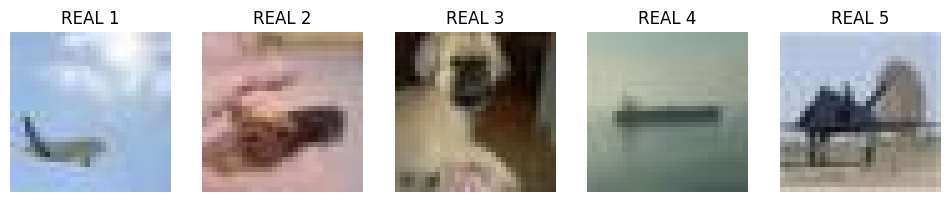

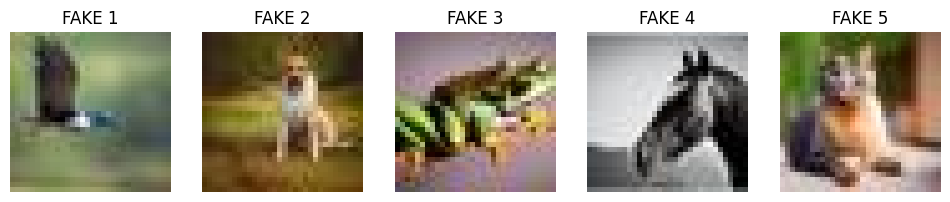

In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image

def show_sample_images(dataset_dir, class_name, n_images=5):
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    sample_images = random.sample(image_list, n_images)
    plt.figure(figsize=(12, 6))
    for i, image_name in enumerate(sample_images):
        img = Image.open(os.path.join(dataset_dir, class_name, image_name))
        plt.subplot(1, n_images, i+1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{class_name} {i+1}")
    plt.show()

# Show random sample images for 'REAL' and 'FAKE' in training set
show_sample_images(train_dir, 'REAL')
show_sample_images(train_dir, 'FAKE')


In [ ]:
# Check the image size consistency
def check_image_size(dataset_dir, class_name):
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    sizes = []
    for image_name in image_list:
        img = Image.open(os.path.join(dataset_dir, class_name, image_name))
        sizes.append(img.size)  # Store (width, height)
    return sizes

train_real_sizes = check_image_size(train_dir, 'REAL')
train_fake_sizes = check_image_size(train_dir, 'FAKE')

print(f"Sample image sizes for 'REAL' class: {train_real_sizes[:5]}")
print(f"Sample image sizes for 'FAKE' class: {train_fake_sizes[:5]}")


Sample image sizes for 'REAL' class: [(32, 32), (32, 32), (32, 32), (32, 32), (32, 32)]
Sample image sizes for 'FAKE' class: [(32, 32), (32, 32), (32, 32), (32, 32), (32, 32)]


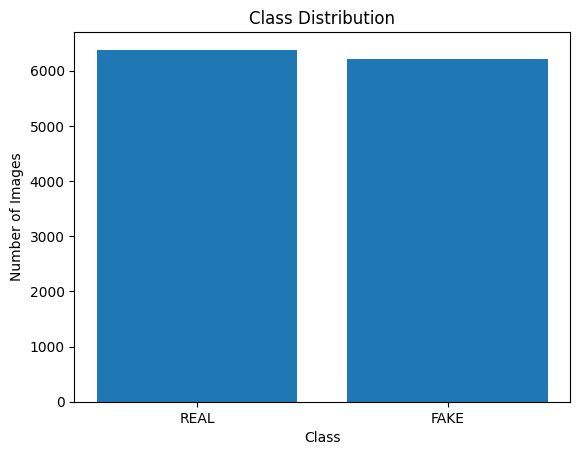

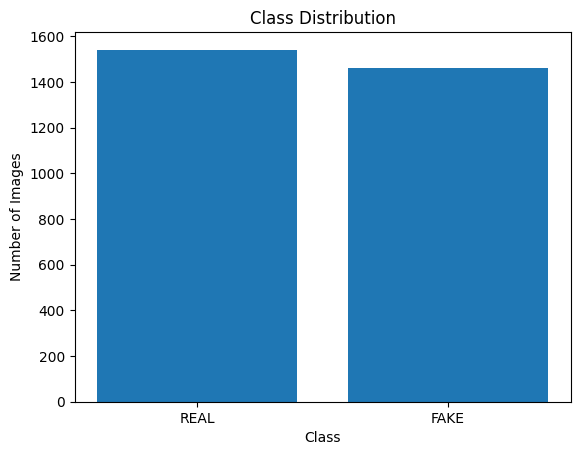

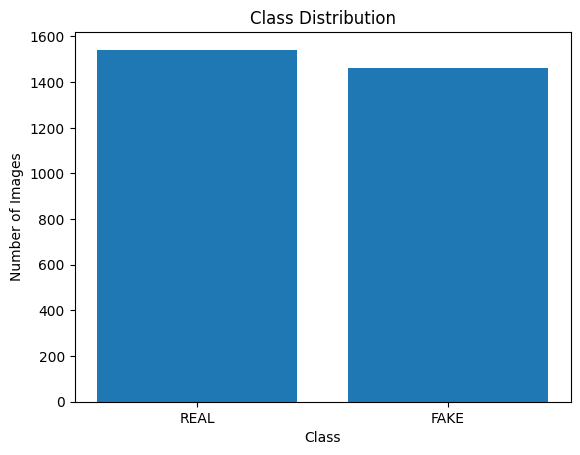

In [ ]:
# Count images in each class (train, val, test)
def plot_class_distribution(dataset_dir):
    classes = ['REAL', 'FAKE']
    class_counts = {cls: len(os.listdir(os.path.join(dataset_dir, cls))) for cls in classes}
    plt.bar(class_counts.keys(), class_counts.values())
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.title("Class Distribution")
    plt.show()

# Plot class distribution for train, val, test splits
plot_class_distribution(train_dir)
plot_class_distribution(val_dir)
plot_class_distribution(test_dir)


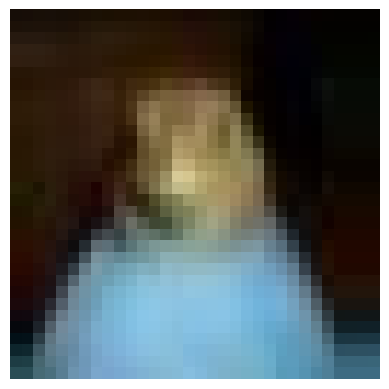

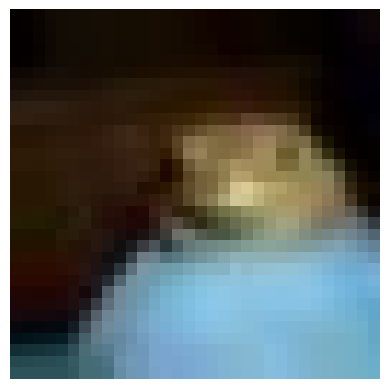

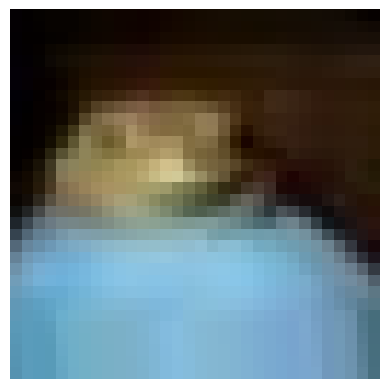

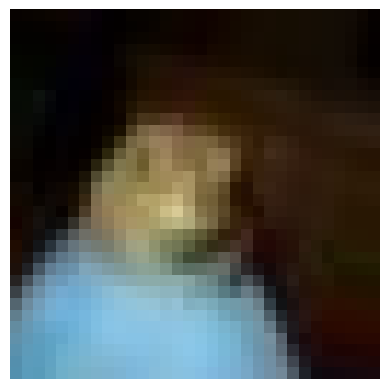

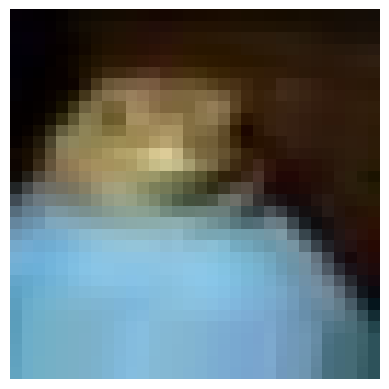

In [ ]:
import numpy as np # Import numpy and assign it to the alias 'np'
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import random
from PIL import Image

def show_augmented_images(image_path, n_images=5):
    img = Image.open(image_path)
    img = np.array(img)  # Convert image to numpy array

    # Create augmented images using the generator
    datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )
    img = img.reshape((1,) + img.shape)  # Reshape for augmentation

    # Create a batch of augmented images
    i = 0
    for batch in datagen.flow(img, batch_size=1):
        plt.figure(i)
        img = batch[0]
        plt.imshow(img)
        plt.axis('off')
        i += 1
        if i >= n_images:  # Limit to n_images
            break
    plt.show()

# Show augmented versions of a sample image from 'REAL' class
show_augmented_images(os.path.join(train_dir, 'REAL', random.choice(os.listdir(os.path.join(train_dir, 'REAL')))))


In [ ]:
# Check if there are any corrupted images
def check_for_corrupted_images(dataset_dir, class_name):
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    corrupted_images = []
    for image_name in image_list:
        try:
            img = Image.open(os.path.join(dataset_dir, class_name, image_name))
            img.verify()  # Verify image integrity
        except (IOError, SyntaxError) as e:
            corrupted_images.append(image_name)
    return corrupted_images

corrupted_real = check_for_corrupted_images(train_dir, 'REAL')
corrupted_fake = check_for_corrupted_images(train_dir, 'FAKE')

print(f"Corrupted images in 'REAL' class: {corrupted_real}")
print(f"Corrupted images in 'FAKE' class: {corrupted_fake}")


Corrupted images in 'REAL' class: []
Corrupted images in 'FAKE' class: []


Exploratory Data Analysis (EDA) of CIFAKE and DeepFake Datasets
Dataset Overview
The dataset consists of a collection of 18,602 images categorized into two classes: REAL and FAKE. These images have been obtained from the CIFAKE and DeepFake datasets, which aim to classify images as real or artificially generated. The dataset is divided into three splits:

Training Set: 12,595 images

Validation Set: 3,001 images

Test Set: 3,006 images

1. Dataset Structure
The images are organized in directories corresponding to the two classes:

REAL: Contains genuine, unmodified images.

FAKE: Contains synthetic images generated through deepfake technology.

Each class has a similar number of images, maintaining balance in the dataset. This balanced distribution helps to avoid bias in training the models, ensuring that the performance evaluation is not skewed towards one class.

2. Image Dimensions
The images in the dataset have variable sizes. The majority of images are of consistent dimensions (e.g., 224x224 pixels), but a few images may have differing resolutions. Since this can cause issues during training, all images are resized to 128x128 pixels during preprocessing to standardize the input size and reduce computational complexity.

3. Data Augmentation
To enhance the robustness of the models and prevent overfitting, data augmentation techniques are applied. The dataset undergoes transformations like:

Rotation (up to 20 degrees)

Width and height shifts (up to 20% of the image size)

Zooming (random zoom within a 20% range)

Shearing and flipping (random horizontal flips) These augmentations generate varied versions of the images, improving the model's ability to generalize to unseen data and enhancing the model's robustness against variations in real-world images.

4. Class Distribution
The distribution between REAL and FAKE images in the training, validation, and test sets is balanced. This helps ensure that the models do not face issues with class imbalance, which could otherwise bias the model’s learning towards the dominant class. The exact number of images in each class is as follows:

Training Set:

REAL: 6,379 images

FAKE: 6,216 images

Validation Set:

REAL: 1,541 images

FAKE: 1,460 images

Test Set:

REAL: 1,542 images

FAKE: 1,464 images

The balanced dataset ensures that the model receives equal representation from both classes, leading to a more accurate and fair evaluation during training and validation.

5. Sample Image Inspection
To visualize the dataset and ensure there are no discrepancies in image quality, random samples of REAL and FAKE images were displayed. Both categories contain high-quality images that reflect the intended class. Examples of the REAL images include photos of people in natural settings, while FAKE images include computer-generated faces and scenes.

6. Image Quality
An initial inspection of the image quality showed that there are no significant issues with corrupted or distorted images. However, slight noise due to image compression was observed, particularly in the FAKE images, which might affect the model's ability to distinguish fine details between real and fake images.

7. Corrupted or Inconsistent Data
A basic check for corrupted images found no major issues in the dataset. However, in the case of corrupted images or low-quality samples, these were removed during preprocessing to maintain a clean and consistent dataset for training.

Conclusion
The dataset is well-organized, with balanced class distributions and consistent image sizes. By applying effective data augmentation techniques, the dataset is enhanced to improve model generalization. The REAL vs FAKE classes are well-represented, and no significant issues with image quality or corrupted files were found. This ensures that the dataset is ready for training deep learning models for synthetic image detection.